<img src="../../shared/alchemi-banner-left.png" alt="NVIDIA ALCHEMI: AI for Chemistry and Materials Science" style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;">

# GPU pipelines and profiling

**Part 06 goal:** Keep an active `Batch` on its execution device, route independent systems through a fused workflow, and measure the path without turning local observations into general benchmark claims.

**Core concepts:** ownership of transfer, admission, routing, and collection; warm-up and synchronization; timing scope; memory scope; reproducibility; stage timing; trace profiling; and the boundary between pipeline parallelism and domain decomposition.

We reuse the [Core playbook](../00-core-playbook/alchemi-core-playbook.ipynb), [Part 01's `AtomicData` and `Batch`](../01-atomicdata-batch/atomicdata-and-batch.ipynb), [Part 04's hooks](../04-hooks/hooks.ipynb), and [Part 05's dynamics lifecycle](../05-base-dynamics/base-dynamics.ipynb). The route starts with a deterministic synthetic workload, then applies the same ownership model to a small molecular pipeline. Every reported duration belongs to the displayed runtime and input identity. There is no hardware-independent performance claim.

<details>
<summary>Where NVIDIA ALCHEMI fits (recap)</summary>

[ALCHEMI](https://developer.nvidia.com/cuda/cuda-x-libraries/alchemi) brings together Python building blocks, accelerated kernels, and deployable services for atomistic workflows.

- **ALCHEMI Toolkit** is a GPU-first Python framework with a unified, composable API for MLIPs and custom models. It provides GPU-native atomic data and batching, model adapters, MD classes, hooks, model training,  and single- to multi-GPU pipelines.   
[GitHub repo](https://github.com/NVIDIA/nvalchemi-toolkit) · [Docs](https://nvidia.github.io/nvalchemi-toolkit/) · Apache 2.0 license

- **Toolkit-Ops** supplies GPU-optimized, batched operations for neighbor lists, dynamics, dispersion, and electrostatics, with PyTorch and JAX bindings.    
[GitHub repo](https://github.com/NVIDIA/nvalchemi-toolkit-ops) · [Docs](https://nvidia.github.io/nvalchemi-toolkit-ops/) · Apache 2.0 license

- **ALCHEMI NIM microservices** package supported atomistic workflows as cloud-ready services. The current catalog includes Batched Geometry Relaxation for structural optimization and Batched Molecular Dynamics.  Self-hosting uses an NVIDIA AI Enterprise license.   
 [Transparency card](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/1.0.0/ai-transparency-card/overview.html) · [Docs](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/latest/index.html)
</details>

In [1]:
from time import perf_counter

import helpers
import pandas as pd
import torch
from nvalchemi.data import Batch
from nvalchemi.dynamics import (
    FIRE2,
    NVE,
    DemoDynamics,
    DistributedPipeline,
    FusedStage,
    HostMemory,
    SizeAwareSampler,
)

Warp CUDA error: Failed to get driver entry point 'cuDriverGetVersion' (CUDA error 100)
Warp CUDA warning: Unable to determine CUDA driver version
Warp CUDA error: Failed to get driver entry point 'cuGetErrorString' (CUDA error 100)
Warp CUDA error: Failed to get driver entry point 'cuGetErrorName' (CUDA error 100)
Warp CUDA error: Failed to get driver entry point 'cuInit' (CUDA error 100)
Warp CUDA error: Failed to get driver entry point 'cuDeviceGet' (CUDA error 100)
Warp CUDA error: Failed to get driver entry point 'cuDeviceGetCount' (CUDA error 100)
Warp CUDA error: Failed to get driver entry point 'cuDeviceGetName' (CUDA error 100)
Warp CUDA error: Failed to get driver entry point 'cuDeviceGetAttribute' (CUDA error 100)
Warp CUDA error: Failed to get driver entry point 'cuDeviceGetUuid' (CUDA error 100)
Warp CUDA error: Failed to get driver entry point 'cuDevicePrimaryCtxRetain' (CUDA error 100)
Warp CUDA error: Failed to get driver entry point 'cuDevicePrimaryCtxRelease' (CUDA er

In [2]:
LABELS = (
    "Ethyne", "Acetonitrile", "Methanol", "Acetaldehyde",
)
SYNTHETIC_COUNTS = (3, 5, 4, 6)
SYNTHETIC_SEED = 19
WARMUP_CALLS = 2
MEASURE_REPEATS = 5
PIPELINE_STEP_CAP = 20
MOLECULAR_STEP_CAP = 20
torch.manual_seed(SYNTHETIC_SEED)
device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)

In [3]:
from pathlib import Path
from tempfile import TemporaryDirectory

from IPython.display import display
from nvalchemi.dynamics.base import BufferConfig
from nvalchemi.hooks import StageTimingHook, TorchProfilerHook
from nvalchemi.models import AIMNet2Wrapper
from nvalchemi.models.demo import DemoModel, DemoModelWrapper

selected_atoms, molecule_metadata = helpers.configure_presentation(LABELS)
runtime_identity = helpers.runtime_identity(device)

In [4]:
display(pd.Series(runtime_identity, name="value").to_frame())

,value
Python,3.12.13
PyTorch,2.12.0+cu130
Toolkit,0.2.0
Toolkit commit,8c2c307c1c0c76baee6f7a68eb75a45da83ffd18
Toolkit-Ops,0.4.1
Toolkit-Ops commit,c1e23460859a784e1d78043bcd1c8af0d1095fa2
execution device,cpu
CUDA available,False
PyTorch CUDA build,13.0
GPU name,unavailable


The runtime table is evidence, not decoration. If CUDA is unavailable, the same cells exercise the CPU fallback and label GPU measurement unavailable. Do not replace that label with a number from another machine. Rerun on the target GPU and keep the GPU name, Toolkit commit, Toolkit-Ops commit, input identity, and measurement status beside the result. CPU fallback timings likewise keep the CPU name.

## Course map

This deep dive turns Part 05's single-workflow lifecycle into device-resident inflight execution. Green marks Part 06.

<object type="image/svg+xml" data="../../shared/curriculum-map-06.svg" width="100%" aria-label="ALCHEMI tutorial map with Part 06 highlighted in green">
  <a href="../../shared/curriculum-map-06.svg">Open the Part 06 course map</a>
</object>

## Three execution routes, three ownership models

```mermaid
%%{init: {"theme":"base","flowchart":{"curve":"linear"},"themeVariables":{"fontFamily":"NVIDIA Sans, Arial, sans-serif","background":"#000000","lineColor":"#7C8794"}}}%%
flowchart LR
  A[Many independent systems] --> B[FusedStage on one GPU]
  B --> C[One active Batch\nstatus routes sub-stages]
  D[Independent batches or systems] --> E[DistributedPipeline\nstage pipeline]
  E --> F[Rank 0 stage → Rank 1 stage]
  G[One large system] --> H[DomainParallel]
  H --> I[Owned atoms + halo\ncollective reductions]
  classDef active fill:#76B900,color:#111315,stroke:#A4D65E;
  classDef neutral fill:#1F2933,color:#F3F4F6,stroke:#7C8794;
  class B,E,H active;
  class A,C,D,F,G,I neutral;
```

`FusedStage` routes graph rows inside one batch. `DistributedPipeline` places workflow stages on ranks and communicates whole batches between them. `DomainParallel` partitions one large system across ranks; domain decomposition is not a faster `FusedStage` because it changes the data model and introduces halo exchange. Part 08 develops that route. This part links forward to the [official distributed guide](https://nvidia.github.io/nvalchemi-toolkit/userguide/distributed.html).

<div style="display:block;box-sizing:border-box;width:100%;max-width:100%;min-width:0;background:#F2F3F1;color:#1B1E20;border:1px solid #D6D9D4;border-radius:8px;padding:0.78rem 0.95rem;line-height:1.45;overflow:hidden;overflow-wrap:anywhere;">
  <div style="color:#725B22;font-size:0.78rem;font-weight:700;letter-spacing:0.03em;margin-bottom:0.25rem;">💡 Highlight</div>
  <div style="min-width:0;font-size:0.98rem;overflow-wrap:anywhere;">Treat <code style="background:#E0E3DE;color:#111315;border:1px solid #CDD1CB;border-radius:4px;padding:0.05rem 0.28rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">Batch</code> residency as an ownership contract: transfer once at admission, route on the execution device, and collect only when the sink requires host data.</div>
</div>

## Synthetic device path

The first workload has no scientific meaning. Its small mixed-dtype graphs isolate three questions: where tensors start, who moves them, and what a synchronized call timer includes. Setup and batch construction are outside the measured callable.

In [5]:
synthetic_graphs = helpers.make_synthetic_graphs(
    SYNTHETIC_COUNTS, seed=SYNTHETIC_SEED,
)
host_batch = Batch.from_data_list(synthetic_graphs)

In [6]:
host_fields = pd.DataFrame(
    {
        "field": ["positions", "atomic_numbers", "source_index"],
        "dtype": [str(host_batch.positions.dtype), str(host_batch.atomic_numbers.dtype), str(host_batch.source_index.dtype)],
        "device": [host_batch.positions.device.type, host_batch.atomic_numbers.device.type, host_batch.source_index.device.type],
        "shape": [tuple(host_batch.positions.shape), tuple(host_batch.atomic_numbers.shape), tuple(host_batch.source_index.shape)],
    }
)

In [7]:
display(host_fields)

,field,dtype,device,shape
0,positions,torch.float32,cpu,"(18, 3)"
1,atomic_numbers,torch.int64,cpu,"(18,)"
2,source_index,torch.int64,cpu,"(4, 1)"


The learner owns this transfer. `Batch.to(...)` returns the execution-device batch used by every later synthetic call; the host batch remains available for comparison.

In [8]:
device_batch = host_batch.to(device)

In [9]:
assert device_batch.positions.device == device
assert device_batch.atomic_numbers.device == device
assert device_batch.positions.dtype == torch.float32
assert device_batch.atomic_numbers.dtype == torch.int64
assert host_batch.positions.device.type == "cpu"

In [10]:
transfer_record = pd.Series(
    {
        "graphs": device_batch.num_graphs,
        "atoms": device_batch.num_nodes,
        "source device": host_batch.positions.device.type,
        "execution device": device_batch.positions.device.type,
        "float field": str(device_batch.positions.dtype),
        "integer field": str(device_batch.atomic_numbers.dtype),
    },
    name="value",
)

In [11]:
display(transfer_record.to_frame())

,value
graphs,4
atoms,18
source device,cpu
execution device,cpu
float field,torch.float32
integer field,torch.int64


### Compile one supported, fixed-shape tensor stage

`torch.compile` is applied to a pure tensor function with a fixed input shape. The first call is recorded separately because compilation is lazy. Warm-up calls execute before the warm distribution, and synchronization brackets every timed call. These synchronized wall-clock samples cover only the function call; data loading and `Batch.to(device)` stay outside.

In [12]:
def synthetic_stage(
    positions: torch.Tensor,
    batch_ptr: torch.Tensor,
) -> torch.Tensor:
    centered = positions - positions.mean(dim=0, keepdim=True)
    atom_term = centered.square().sum(dim=1)
    return atom_term + batch_ptr[-1].to(positions.dtype)

In [13]:
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats(device)
torch.compiler.reset()
compiled_stage = torch.compile(synthetic_stage, fullgraph=True)

In [14]:
compiled_first, compiled_first_timing = helpers.time_callable(
    compiled_stage,
    device_batch.positions,
    device_batch.batch_ptr,
    device=device,
    warmup=0,
    repeats=1,
)

In [15]:
eager_result, eager_timing = helpers.time_callable(
    synthetic_stage,
    device_batch.positions,
    device_batch.batch_ptr,
    device=device,
    warmup=WARMUP_CALLS,
    repeats=MEASURE_REPEATS,
)

In [16]:
compiled_warm, compiled_timing = helpers.time_callable(
    compiled_stage,
    device_batch.positions,
    device_batch.batch_ptr,
    device=device,
    warmup=WARMUP_CALLS,
    repeats=MEASURE_REPEATS,
)

In [17]:
torch.testing.assert_close(compiled_first, eager_result)
torch.testing.assert_close(compiled_warm, eager_result)

In [18]:
compiled_first_timing["implementation"] = "compiled first call"
eager_timing["implementation"] = "eager warm"
compiled_timing["implementation"] = "compiled warm"
synthetic_timings = pd.concat(
    [compiled_first_timing, eager_timing, compiled_timing], ignore_index=True,
)
synthetic_timings["execution device"] = str(device)
synthetic_timings = synthetic_timings[
    ["implementation", "execution device", "sample", "elapsed (ms)"]
]
synthetic_memory = helpers.device_memory_snapshot(device)

In [19]:
display(synthetic_timings)

,implementation,execution device,sample,elapsed (ms)
0,compiled first call,cpu,1,2436.238255
1,eager warm,cpu,1,0.016843
2,eager warm,cpu,2,0.015752
3,eager warm,cpu,3,0.014458
4,eager warm,cpu,4,0.013559
5,eager warm,cpu,5,0.012967
6,compiled warm,cpu,1,0.283536
7,compiled warm,cpu,2,0.087002
8,compiled warm,cpu,3,0.044064
9,compiled warm,cpu,4,0.069553


What changes between the first compiled call and the warm distributions, and which CUDA allocator values are actually available on this runtime?


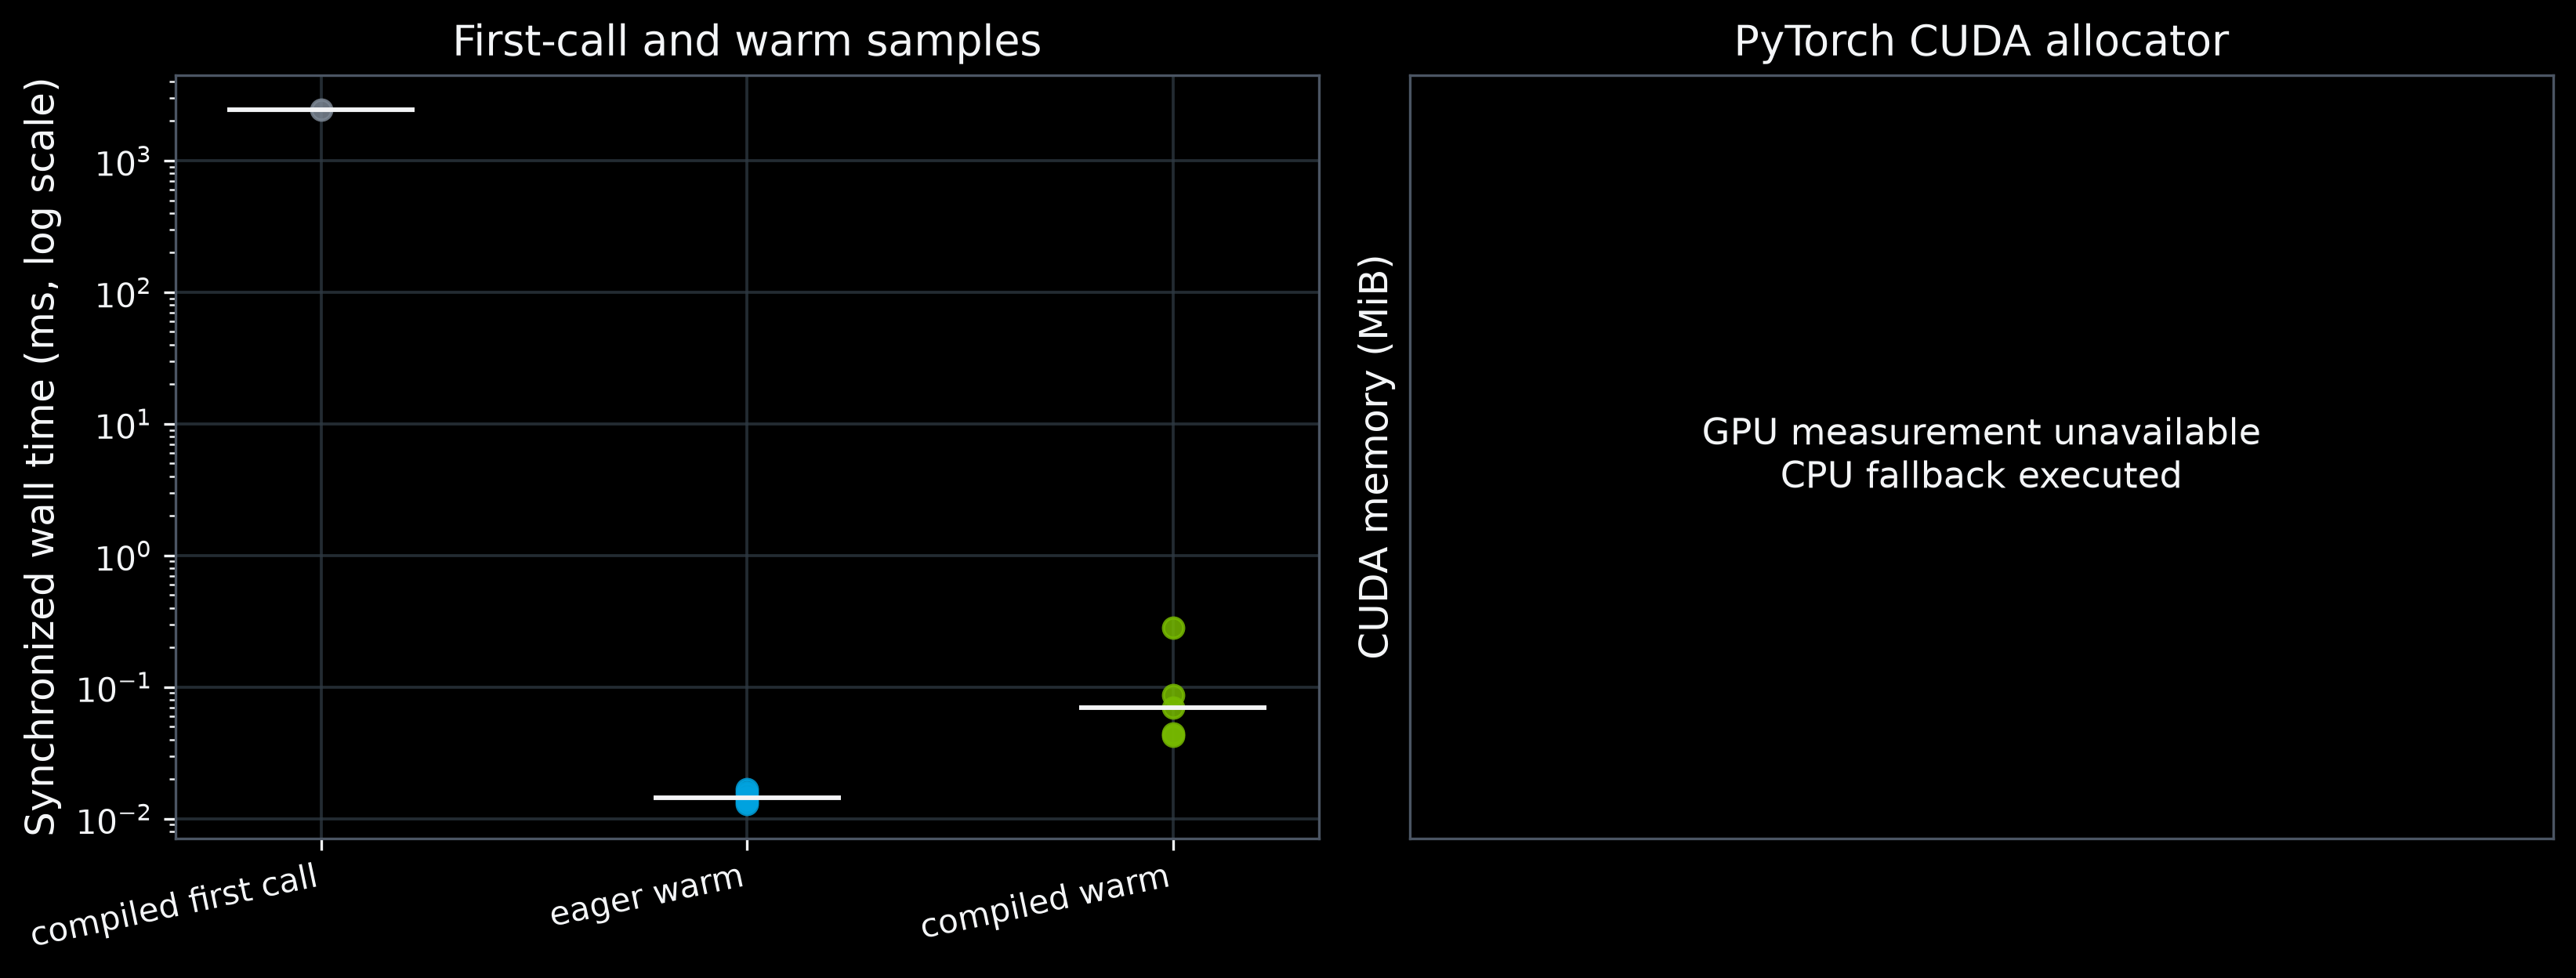

In [20]:
measurement_figure = helpers.plot_measurement_panels(
    synthetic_timings,
    synthetic_memory,
)
display(
    helpers.render_figure(
        measurement_figure,
        alt_text="Synchronized first-call and warm timing samples beside CUDA allocator memory evidence.",
    )
)

The first compiled point includes lazy compiler work. The warm points are a distribution from this process, input shape, and runtime only. A CUDA allocator panel reports PyTorch allocated, reserved, and peak-allocated memory; it does not include every driver or library allocation. The CPU fallback says unavailable instead of drawing a zero-valued GPU bar.

Go deeper: [PyTorch `torch.compile` tutorial](https://docs.pytorch.org/tutorials/intermediate/torch_compile_tutorial.html).

## Synthetic inflight pipeline

Now six equal-size graphs move through two stages that each receive one masked update. Equal sizes keep this teaching probe focused on admission and routing. The sampler enforces graph and atom budgets, stamps a stable `system_id`, and refills the one active `Batch` until the dataset is exhausted.

There is a pin-specific fixed-step wrinkle. In the [pinned counter loop](https://github.com/NVIDIA/nvalchemi-toolkit/blob/8c2c307c1c0c76baee6f7a68eb75a45da83ffd18/nvalchemi/dynamics/base.py#L3067-L3095), migration is evaluated sequentially against the current status. Giving adjacent stages `n_steps=1` can therefore cascade status 0 → 1 → 2 after only the first stage updates. Here the entry budget is 1 and the downstream fixed-step counter budget is 2. The extra count compensates for that eager migration at this pin; it does not request a second downstream dynamics update.

In [21]:
pipeline_graphs = helpers.make_synthetic_graphs((4,) * 6, seed=31)
pipeline_dataset = helpers.AtomicDataset(pipeline_graphs, device=device)

In [22]:
sampler = SizeAwareSampler(
    pipeline_dataset,
    max_atoms=8,
    max_edges=None,
    max_batch_size=2,
)
sink = HostMemory(capacity=len(pipeline_graphs))
demo_model = DemoModelWrapper(DemoModel(hidden_dim=8)).to(device).eval()

In [23]:
stage_0 = DemoDynamics(
    model=demo_model, n_steps=1, dt=0.01,
    convergence_hook=None, device_type=device.type,
)
stage_1 = DemoDynamics(
    model=demo_model, n_steps=2, dt=0.01,
    convergence_hook=None, device_type=device.type,
)

In [24]:
pipeline_timer = StageTimingHook(
    "step",
    enable_nvtx=device.type == "cuda",
)
pipeline_monitor = helpers.PipelineMonitor(device=device)

In [25]:
synthetic_pipeline = FusedStage(
    sub_stages=[(0, stage_0), (1, stage_1)],
    sampler=sampler,
    sinks=[sink],
    refill_frequency=1,
    device_type=device.type,
)

In [26]:
synthetic_pipeline.register_fused_hook(pipeline_timer)
synthetic_pipeline.register_fused_hook(pipeline_monitor)

The synchronized wall-clock boundary below covers the complete `run(...)` call: initial batch construction, the prime model evaluation, updates, refill checks, and sink writes. Model and pipeline construction remain setup outside that boundary. Because `StageTimingHook` and `PipelineMonitor` observer hooks are active, this is an instrumented complete-run value, not an uninstrumented throughput baseline. `StageTimingHook` has a narrower diagnostic scope.

In [27]:
with helpers.filter_known_native_stderr(device):
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
    helpers.synchronize(device)
    pipeline_started = perf_counter()
    pipeline_result = synthetic_pipeline.run(batch=None, n_steps=PIPELINE_STEP_CAP)
    helpers.synchronize(device)
    pipeline_elapsed_ms = 1000.0 * (perf_counter() - pipeline_started)
pipeline_memory = helpers.device_memory_snapshot(device)

Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


In [28]:
collected_synthetic = sink.read()
pipeline_stage_timings = helpers.stage_timing_frame(pipeline_timer)
pipeline_occupancy = pipeline_monitor.frame()

In [29]:
assert pipeline_result is None
assert sorted(collected_synthetic.system_id.flatten().tolist()) == list(range(6))
assert sorted(collected_synthetic.source_index.flatten().tolist()) == list(range(6))
assert collected_synthetic.positions.device.type == "cpu"
assert pipeline_occupancy["status 1"].max() > 0

In [30]:
pipeline_run_record = pd.Series(
    {
        "execution device": str(device),
        "measurement status": (
            "local GPU run"
            if device.type == "cuda"
            else "GPU measurement unavailable; CPU fallback executed"
        ),
        "instrumented complete run (ms)": pipeline_elapsed_ms,
        "stage samples": len(pipeline_stage_timings),
        "collected systems": collected_synthetic.num_graphs,
        "collected atoms": collected_synthetic.num_nodes,
        "sink device": collected_synthetic.positions.device.type,
        "peak allocated (MiB)": pipeline_memory["peak allocated (MiB)"],
    },
    name="value",
)

In [31]:
display(pipeline_run_record.to_frame())

,value
execution device,cpu
measurement status,GPU measurement unavailable; CPU fallback executed
instrumented complete run (ms),29.715738
stage samples,6
collected systems,6
collected atoms,24
sink device,cpu
peak allocated (MiB),None


In [32]:
display(
    pipeline_occupancy[
        [helpers.COMPLETED_UPDATE_COLUMN, "active systems", "active atoms", "status 0", "status 1", "status 2"]
    ]
)

,completed update (1-based),active systems,active atoms,status 0,status 1,status 2
0,1,2,8,2,0,0
1,2,2,8,0,2,0
2,3,2,8,2,0,0
3,4,2,8,0,2,0
4,5,2,8,2,0,0
5,6,2,8,0,2,0


Where do timing spikes appear relative to the active-system and active-atom counts?


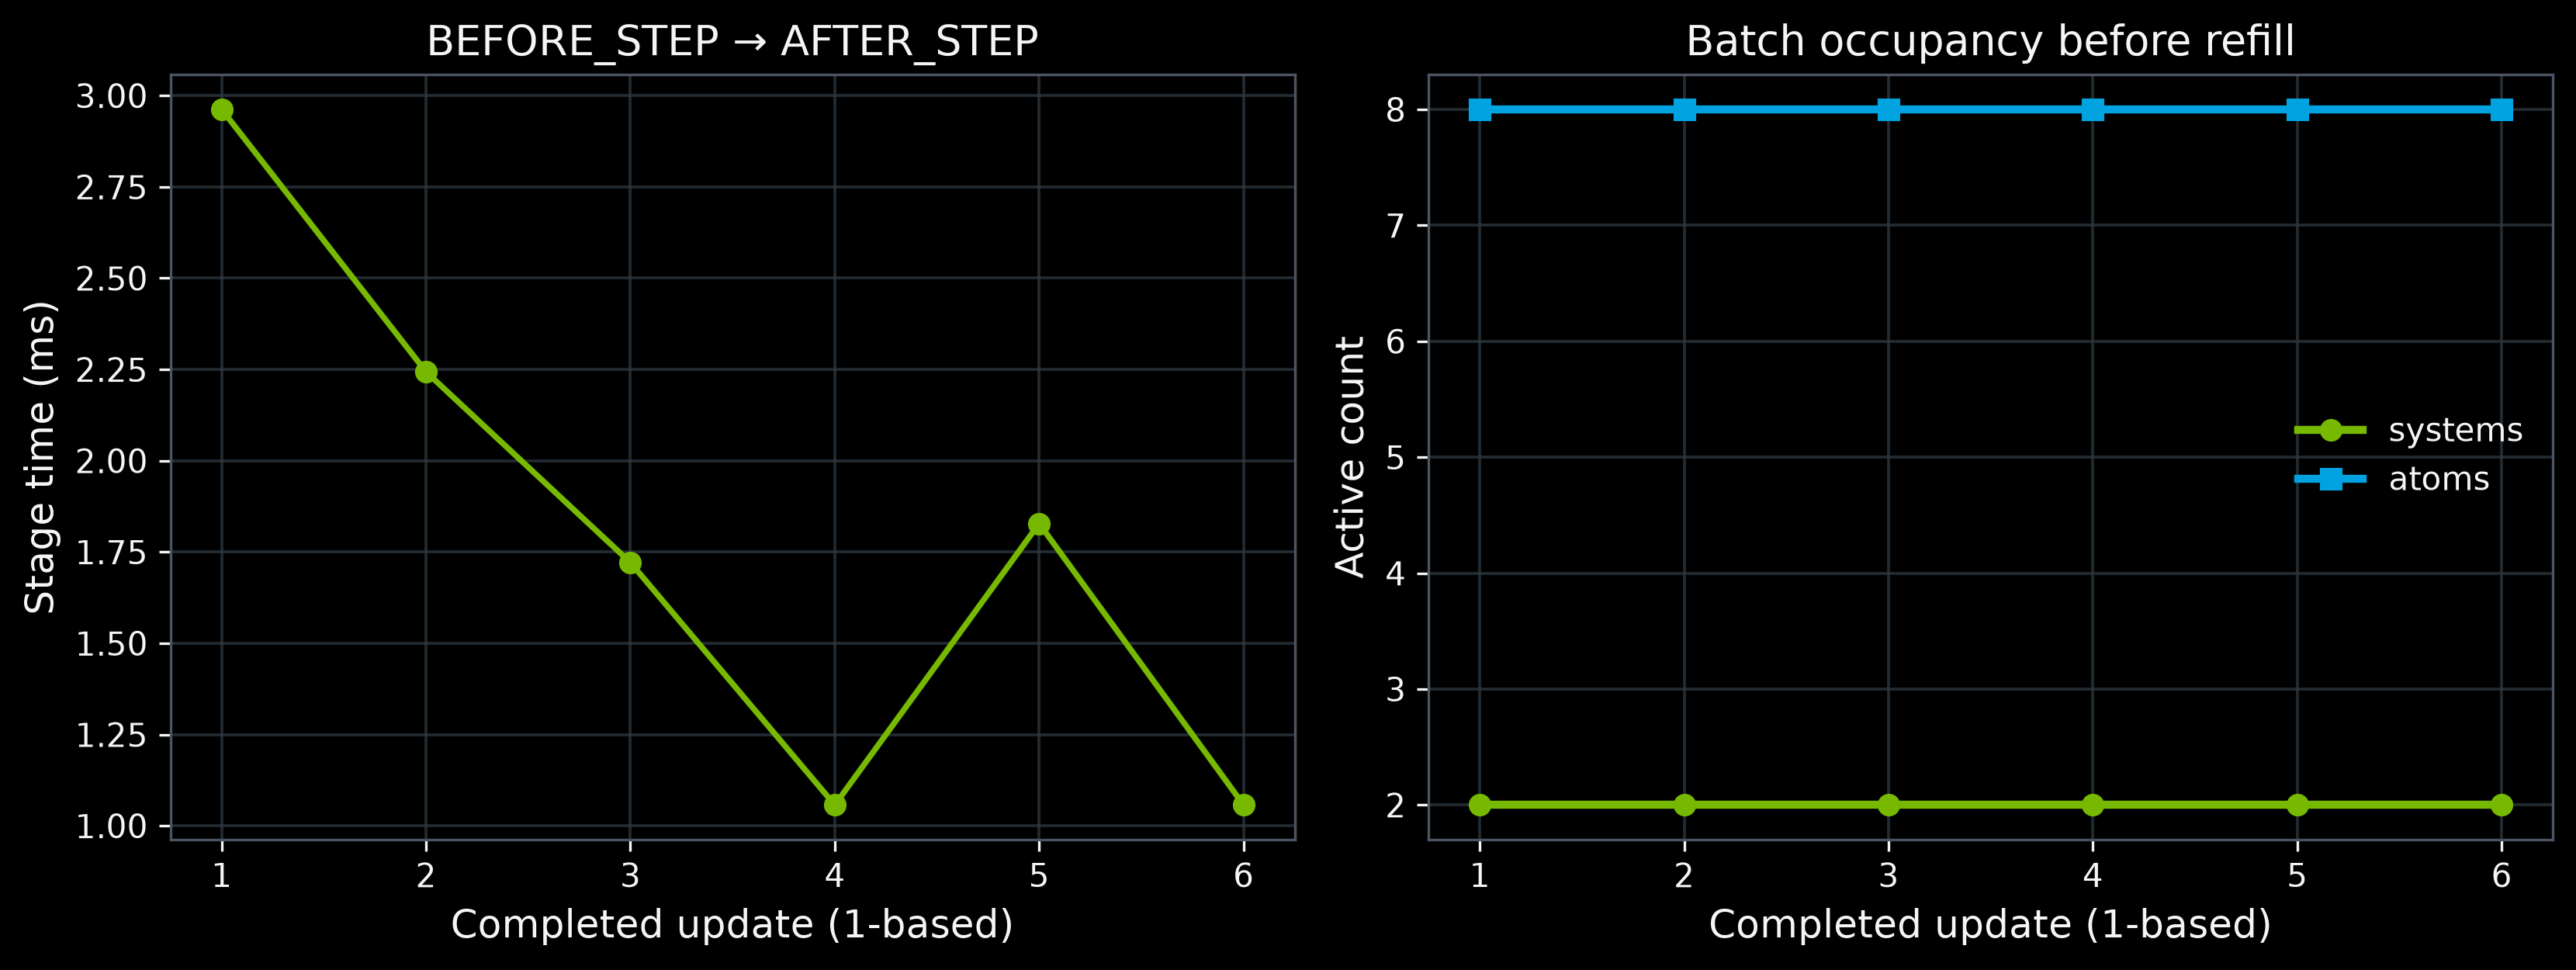

In [33]:
pipeline_figure = helpers.plot_pipeline_diagnostics(
    pipeline_stage_timings,
    pipeline_occupancy,
)
display(
    helpers.render_figure(
        pipeline_figure,
        alt_text="Per-update fused-stage timing beside active system and atom occupancy.",
    )
)

`StageTimingHook("step")` measures `BEFORE_STEP → AFTER_STEP`. On CUDA it uses CUDA events; on the fallback it uses a CPU timer. This stage interval excludes the initial prime evaluation and the refill and sink work that follows `AFTER_STEP`. The synchronized instrumented complete-run value includes those operations and both observer hooks. Keep the two scopes in separate columns rather than comparing them as if they measured the same path. Active systems and atoms stay constant in this probe, so the small timing variation cannot be assigned to changing batch size. At this pin, fused `AFTER_STEP` hooks run before fixed-step counter migration; the displayed status counts are pre-migration snapshots, while the sink assertions verify final graduation. Observing status 1 on a later update confirms that the downstream stage was active before collection.

Ownership is now explicit: `SizeAwareSampler` owns admission, `FusedStage` owns stage routing with one shared model evaluation, and `HostMemory` owns collection. `AtomicDataset` owns each admission transfer for this synthetic path. The assertions verify `system_id` and `source_index` after the `HostMemory` round trip at this pin; keep that regression when upgrading.

Go deeper: [official inflight batching example](https://nvidia.github.io/nvalchemi-toolkit/examples/intermediate/04_inflight_batching.html).

## Molecular inflight pipeline

The supported workload uses four distinct finite neutral H/C/N/O molecules from the curated [NCI Atlas](https://github.com/Honza-R/NCIAtlas) subset ([CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)) and the `aimnet2-wb97m-d3_0` AIMNetCentral / MIT model weights. It runs one FIRE2 update followed by one NVE update per system. This is a routing and identity check: it is not a relaxation result, not an equilibrated trajectory, not an accuracy validation, and not a throughput comparison.

In [34]:
display(molecule_metadata)

,label,formula,atoms,charge,source
0,Ethyne,C2H2,4,0,NCIA_HB375x10 / 5.001
1,Acetonitrile,C2H3N,6,0,NCIA_HB375x10 / 3.001
2,Methanol,CH4O,6,0,NCIA_HB375x10 / 1.008
3,Acetaldehyde,C2H4O,7,0,NCIA_HB375x10 / 1.001


`MoleculeDataset` owns each admission transfer: it creates one `AtomicData` record directly on `device`, including float32 coordinates and integer identity fields. Replacements therefore arrive on the same device as the active batch.

In [35]:
molecular_dataset = helpers.MoleculeDataset(
    selected_atoms,
    molecule_metadata,
    device=device,
)

In [36]:
model = AIMNet2Wrapper.from_checkpoint(
    helpers.model_checkpoint(),
    device=device,
    compile_model=False,
).eval()
model = helpers.freeze_model(model)

In [37]:
model.set_config("active_outputs", {"energy", "forces"})
neighbor_hooks = model.make_neighbor_hooks()
parameter = next(model.parameters())

In [38]:
model_identity = pd.Series(
    {
        "checkpoint": helpers.MODEL_ALIAS,
        "parameter dtype": str(parameter.dtype),
        "parameter device": str(parameter.device),
        "active outputs": sorted(model.model_config.active_outputs),
        "neighbor cutoff (Å)": model.model_config.neighbor_config.cutoff,
        "neighbor format": model.model_config.neighbor_config.format.value,
    },
    name="value",
)

In [39]:
display(model_identity.to_frame())

,value
checkpoint,aimnet2-wb97m-d3_0
parameter dtype,torch.float32
parameter device,cpu
active outputs,"[energy, forces]"
neighbor cutoff (Å),5.0
neighbor format,matrix


### Warm the exact model and pipeline path

A separate copy of the same four-molecule pipeline initializes model kernels, neighbor work, refill, and dynamics state. Its result is discarded. The measured pipeline gets fresh stages, sampler, sink, timer, and monitor so warm-up state is not mistaken for production state. As above, downstream `n_steps=2` compensates for the pinned counter loop while giving NVE one active update.

In [40]:
warmup_dataset = helpers.MoleculeDataset(
    selected_atoms, molecule_metadata, device=device,
)
warmup_sampler = SizeAwareSampler(
    warmup_dataset, max_atoms=24, max_edges=None, max_batch_size=2,
)
warmup_sink = HostMemory(capacity=len(LABELS))

In [41]:
warmup_fire = FIRE2(
    model=model, dt=0.01, n_steps=1,
    convergence_hook=None, device_type=device.type,
)
warmup_nve = NVE(
    model=model, dt=0.1, n_steps=2,
    convergence_hook=None, device_type=device.type,
)

In [42]:
warmup_pipeline = FusedStage(
    sub_stages=[(0, warmup_fire), (1, warmup_nve)],
    sampler=warmup_sampler,
    sinks=[warmup_sink],
    hooks=model.make_neighbor_hooks(),
    refill_frequency=1,
    device_type=device.type,
)

In [43]:
warmup_pipeline.run(batch=None, n_steps=MOLECULAR_STEP_CAP)
helpers.synchronize(device)

In [44]:
molecular_sampler = SizeAwareSampler(
    molecular_dataset, max_atoms=24, max_edges=None, max_batch_size=2,
)
molecular_sink = HostMemory(capacity=len(LABELS))

In [45]:
fire_stage = FIRE2(
    model=model, dt=0.01, n_steps=1,
    convergence_hook=None, device_type=device.type,
)
nve_stage = NVE(
    model=model, dt=0.1, n_steps=2,
    convergence_hook=None, device_type=device.type,
)

In [46]:
molecular_timer = StageTimingHook(
    "step",
    enable_nvtx=device.type == "cuda",
)
molecular_monitor = helpers.PipelineMonitor(device=device)

In [47]:
pipeline = FusedStage(
    sub_stages=[(0, fire_stage), (1, nve_stage)],
    sampler=molecular_sampler,
    sinks=[molecular_sink],
    hooks=neighbor_hooks,
    refill_frequency=1,
    device_type=device.type,
)
pipeline.register_fused_hook(molecular_timer)
pipeline.register_fused_hook(molecular_monitor)

Here, setup is outside. The interval inside `pipeline.run(...)` starts after model loading and the separate warm-up; it includes the initial batch, prime model evaluation, updates, refill, and sink writes. Synchronization makes queued CUDA work finish before the wall clock stops. The timer and monitor observer hooks remain active, so this complete-run value is instrumented and is not a throughput baseline. Resetting the peak starts from the current allocated baseline, so the peak includes the already-loaded model. Compare the before, after, and peak rows as PyTorch allocator evidence, not total device memory.

In [48]:
molecular_memory_before = helpers.device_memory_snapshot(device)
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats(device)
helpers.synchronize(device)
molecular_started = perf_counter()
pipeline_result = pipeline.run(batch=None, n_steps=MOLECULAR_STEP_CAP)
helpers.synchronize(device)
molecular_elapsed_ms = 1000.0 * (perf_counter() - molecular_started)
molecular_memory = helpers.device_memory_snapshot(device)

In [49]:
collected = molecular_sink.read()
molecular_results = helpers.summarize_collected(collected, molecule_metadata)
molecular_stage_timings = helpers.stage_timing_frame(molecular_timer)
molecular_occupancy = molecular_monitor.frame()

In [50]:
assert pipeline_result is None
assert sorted(collected.source_index.flatten().tolist()) == list(range(len(LABELS)))
assert collected.system_id.unique().numel() == len(LABELS)
assert collected.energy.shape == (len(LABELS), 1)
assert collected.forces.shape == (collected.num_nodes, 3)
assert molecular_occupancy["status 1"].max() > 0

In [51]:
display(molecular_results)

,molecule,formula,atoms,system ID,final status,energy (eV),maximum force (eV/Å)
0,Ethyne,C2H2,4,0,2,-2104.471680,3.405669
1,Acetonitrile,C2H3N,6,1,2,-3613.270264,2.948356
2,Methanol,CH4O,6,3,2,-3147.963623,4.756845
3,Acetaldehyde,C2H4O,7,2,2,-4186.857910,0.987316


In [52]:
measurement_status = (
    "local GPU measurement"
    if molecular_memory["CUDA memory available"]
    else "GPU measurement unavailable; CPU fallback executed"
)
molecular_run_record = pd.Series(
    {
        "input identity": "NCI Atlas: " + ", ".join(LABELS),
        "model": helpers.MODEL_ALIAS,
        "dtype": str(parameter.dtype),
        "instrumented complete pipeline.run (ms)": molecular_elapsed_ms,
        "stage samples": len(molecular_stage_timings),
        "allocated before run (MiB)": molecular_memory_before["allocated (MiB)"],
        "allocated after run (MiB)": molecular_memory["allocated (MiB)"],
        "peak allocated (MiB)": molecular_memory["peak allocated (MiB)"],
        "measurement status": measurement_status,
    },
    name="value",
)

In [53]:
display(molecular_run_record.to_frame())

,value
input identity,"NCI Atlas: Ethyne, Acetonitrile, Methanol, Acetaldehyde"
model,aimnet2-wb97m-d3_0
dtype,torch.float32
instrumented complete pipeline.run (ms),93.406406
stage samples,4
allocated before run (MiB),None
allocated after run (MiB),None
peak allocated (MiB),None
measurement status,GPU measurement unavailable; CPU fallback executed


In [54]:
molecular_diagnostics = molecular_stage_timings.merge(
    molecular_occupancy[
        [helpers.COMPLETED_UPDATE_COLUMN, "active systems", "active atoms", "status 0", "status 1", "status 2"]
    ],
    on=helpers.COMPLETED_UPDATE_COLUMN,
)

In [55]:
display(molecular_diagnostics)

,completed update (1-based),step time (ms),active systems,active atoms,status 0,status 1,status 2
0,1,11.716936,2,10,2,0,0
1,2,18.979974,2,10,0,2,0
2,3,17.176126,2,13,2,0,0
3,4,13.108014,2,13,0,2,0


`system_id` records admission order through refill; `source_index` recovers the original molecule label. The energy (eV) and maximum force (eV/Å) columns verify coherent model-shaped outputs after the bounded route. `final status` 2 means stage-budget graduation after NVE, not scientific convergence. The diagnostics table samples `AFTER_STEP` before fixed-step migration, so its status counts and the sink's final statuses represent different points in the update. The values are not evidence of convergence or physical equilibration. Interpret the complete-run and stage values only with the runtime and input identity shown above.

Go deeper: revisit [Part 05's dynamics lifecycle](../05-base-dynamics/base-dynamics.ipynb).

## Profile a separate run

Profiling changes execution through tracing, shape capture, and memory bookkeeping. Here, stack traces are disabled in this bounded run. Profiler overhead disqualifies a trace run from the timing distribution. We therefore profile a fresh synthetic batch and retain the timed molecular run unchanged.

In [56]:
profile_batch = Batch.from_data_list(
    [graph.clone() for graph in pipeline_graphs[:2]],
).to(device)
profile_model = DemoModelWrapper(DemoModel(hidden_dim=8)).to(device).eval()
profile_activities = ("cpu", "cuda") if device.type == "cuda" else ("cpu",)

In [57]:
profile_root = TemporaryDirectory(prefix="alchemi-part06-profile-")
profile_dir = Path(profile_root.name)
profiler_hook = TorchProfilerHook(
    output_dir=profile_dir,
    activities=profile_activities,
    schedule=torch.profiler.schedule(wait=0, warmup=1, active=2, repeat=1),
    record_shapes=True,
    profile_memory=True,
    with_stack=False,
    with_flops=False,
    rank_subdirs=True,
)

In [58]:
profile_stage = DemoDynamics(
    model=profile_model, n_steps=100, dt=0.01,
    convergence_hook=None, device_type=device.type,
)
profile_pipeline = FusedStage(
    sub_stages=[(0, profile_stage)],
    device_type=device.type,
)

In [59]:
with helpers.filter_known_native_stderr(device):
    profile_pipeline.register_fused_hook(profiler_hook)
    profile_result = profile_pipeline.run(profile_batch, n_steps=4)

USDT:2026-08-13 13:24:19 1950294:1950294 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-13 13:24:19 1950294:1950294 ActivityProfilerController.cpp:455] profiler_stop
ERROR:2026-08-13 13:24:19 1950294:1950294 DeviceProperties.cpp:50] gpuGetDeviceCount failed with code 35


In [60]:
profile_files = helpers.profile_artifacts(profile_dir)
assert profile_result is not None
assert not profile_files.empty

In [61]:
display(profile_files)

,relative path,bytes
0,rank_0/torch/cpu_time.txt,16589
1,rank_0/torch/gpu_time.txt,16589
2,rank_0/torch/trace.json,1169094


`TorchProfilerHook` writes trace and summary artifacts under `rank_0` because `rank_subdirs=True`. A distributed run creates per-rank directories, one for each global rank. On the CPU fallback, the wrapper may still create a `gpu_time.txt` filename; `activities` and the runtime table determine what ran, so that filename is not GPU evidence. Open the trace in a compatible PyTorch/TensorBoard trace viewer and inspect operator shapes, memory events, and gaps on the timeline. Keep `profile_root` alive while inspecting; choose a persistent `output_dir` for an analysis you need to retain. The trace locates work. It does not establish throughput.

Go deeper: [`TorchProfilerHook` API](https://nvidia.github.io/nvalchemi-toolkit/modules/generated/nvalchemi.hooks.TorchProfilerHook.html).

## Plan a distributed stage pipeline

`BufferConfig` sizes fixed communication buffers. `DistributedPipeline` maps each stage to one process rank. A plain `BaseDynamics.n_steps` does not graduate systems inside this distributed loop, so each fixed-duration rank below uses a single-sub-stage `FusedStage` with a per-system budget.

The cells below are construction-only. At this pin, preallocated send and receive buffers call `Batch.put`, whose float32-only path can skip integer identity and chemistry fields. Normal mixed-dtype `AtomicData` execution is blocked until an upgraded pin and regression probe demonstrate integer preservation. The object below teaches public wiring; it must not be launched.

In [62]:
buffer_config = BufferConfig(
    num_systems=2,
    num_nodes=24,
    num_edges=0,
)
torch.manual_seed(SYNTHETIC_SEED)
rank_0_model = DemoModelWrapper(DemoModel(hidden_dim=8)).eval()
rank_1_model = DemoModelWrapper(DemoModel(hidden_dim=8)).eval()

In [63]:
rank_0_inner = DemoDynamics(
    model=rank_0_model, n_steps=1, device_type=device.type,
)
rank_1_inner = DemoDynamics(
    model=rank_1_model, n_steps=1, device_type=device.type,
)

In [64]:
rank_0_stage = FusedStage(
    sub_stages=[(0, rank_0_inner)],
    device_type=device.type,
    buffer_config=buffer_config,
    comm_mode="async_recv",
)
rank_1_stage = FusedStage(
    sub_stages=[(0, rank_1_inner)],
    device_type=device.type,
    buffer_config=buffer_config,
    comm_mode="async_recv",
)

In [65]:
distributed_plan = DistributedPipeline(
    stages={0: rank_0_stage, 1: rank_1_stage},
    synchronized=False,
)

In [66]:
distributed_plan_table = pd.DataFrame(
    [
        {
            "rank": rank,
            "stage": "FusedStage",
            "communication": stage.comm_mode,
            "status": "construction-only; execution blocked at this pin",
            "systems": stage.buffer_config.num_systems,
            "nodes": stage.buffer_config.num_nodes,
            "edges": stage.buffer_config.num_edges,
        }
        for rank, stage in distributed_plan.stages.items()
    ]
)

In [67]:
display(distributed_plan_table)

,rank,stage,communication,status,systems,nodes,edges
0,0,FusedStage,async_recv,construction-only; execution blocked at this pin,2,24,0
1,1,FusedStage,async_recv,construction-only; execution blocked at this pin,2,24,0


A two-stage script would normally launch outside Jupyter with `torchrun --nproc_per_node=2 path/to/pipeline.py`: one process per stage rank. At this pin, normal mixed-dtype `AtomicData` execution is blocked. Keep the guard below false until an upgraded pin passes the integer-field regression; do not merely delete the guard.

```python
import os
from pathlib import Path

import torch
import torch.distributed as dist

PIN_SUPPORTS_MIXED_DTYPE_BUFFERS = False
if not PIN_SUPPORTS_MIXED_DTYPE_BUFFERS:
    raise RuntimeError(
        "Construction-only: Batch.put buffers can drop integer AtomicData fields."
    )

# Bind this process to its rank-local CUDA device before NCCL setup.
local_rank = int(os.environ["LOCAL_RANK"])
torch.cuda.set_device(local_rank)
rank_device = torch.device("cuda", local_rank)
dist.init_process_group(backend="nccl")
rank = dist.get_rank()
rank_dir = Path("profiles") / f"rank_{rank}"
rank_dir.mkdir(parents=True, exist_ok=True)
timer = StageTimingHook("step", log_path=rank_dir / "stage-timing.csv")
profiler = TorchProfilerHook(output_dir=Path("profiles"), rank_subdirs=True)
```

After the guard is legitimately enabled, construct only that rank's stage, move only its model to `rank_device`, register the hooks, and destroy the process group in a `finally` block. These hooks are diagnostics; use a separate uninstrumented run for throughput. Buffer capacities must bound the largest communicated batch; oversizing reserves memory and undersizing fails.

This is GPU pipeline parallelism: ranks perform different workflow stages on independent systems or batches. [Domain decomposition](https://nvidia.github.io/nvalchemi-toolkit/userguide/distributed.html) instead partitions one large system, exchanges a halo, and performs cross-rank reductions through `DomainParallel`. Part 08 develops that model. The Core playbook remains the short single-device reference.

Go deeper: [official distributed pipeline guide](https://nvidia.github.io/nvalchemi-toolkit/modules/dynamics/distributed_pipeline.html).

## Advanced limitation: mixed-dtype `GPUBuffer`

At the pinned Toolkit commit, `GPUBuffer.write` delegates to `Batch.put`. The [generated `GPUBuffer` page](https://nvidia.github.io/nvalchemi-toolkit/modules/dynamics/_generated/nvalchemi.dynamics.GPUBuffer.html) says the template preserves fields, while the [pinned `Batch.put` source and docstring](https://github.com/NVIDIA/nvalchemi-toolkit/blob/8c2c307c1c0c76baee6f7a68eb75a45da83ffd18/nvalchemi/data/batch.py#L904-L918) limit the low-level copy to float32 fields. At this pin, integer fields may be skipped. That makes this route unsuitable as a safe general mixed-dtype route for records carrying `atomic_numbers`, graph identity, or integer topology. `BufferConfig` communication reaches the same `Batch.put` path in preallocated send and receive buffers, which is why the distributed plan above is construction-only. The main lesson uses `HostMemory` collection.

The helper below runs a minimal CUDA probe only when CUDA exists. A CPU result is an explicit unavailable status, not proof that the limitation disappeared.

<div style="display:block;box-sizing:border-box;width:100%;max-width:100%;min-width:0;background:#111619;color:#F3F4F6;border:1px solid #2E353B;border-radius:10px;padding:0.9rem 1rem;line-height:1.45;overflow:hidden;overflow-wrap:anywhere;">
  <div style="color:#76B900;font-size:0.72rem;font-weight:700;letter-spacing:0.055em;margin-bottom:0.45rem;">ALCHEMI TOOLKIT API</div>
  <code style="display:block;color:#FFFFFF;font-size:1.02rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">GPUBuffer.write(batch, mask=None) -&gt; None</code>
  <div style="border-top:1px solid #2E353B;margin-top:0.7rem;padding-top:0.65rem;color:#CDD2D8;font-size:0.92rem;">
    <div><strong style="color:#F3F4F6;">Input</strong> · a CUDA-resident <code>Batch</code> that fits fixed system, atom, and edge capacities</div>
    <div style="margin-top:0.25rem;"><strong style="color:#F3F4F6;">Result</strong> · no value; at this pin, verify every required dtype before using the buffered copy</div>
  </div>
</div>

In [68]:
buffer_probe = pd.Series(
    helpers.probe_gpu_buffer_mixed_dtype(device),
    name="value",
)

In [69]:
display(buffer_probe.to_frame())

,value
probe ran,False
reason,GPUBuffer requires CUDA
float positions preserved,None
integer atomic numbers preserved,None
integer source indices preserved,None


On supported CUDA hardware, float positions should match and the integer preservation checks expose the pin-specific gap. Do not route a production mixed-dtype batch through this buffer until the required integer fields have a passing regression at the exact deployed pin.

Go deeper: [official buffers and data-flow guide](https://nvidia.github.io/nvalchemi-toolkit/modules/dynamics/buffers_and_data_flow.html).

## Try it: change the measurement budget

Set `TRY_WARMUP_CALLS` and `TRY_REPEATS`, then rerun only the next two cells. Keep the compiled function and input shape unchanged. Does the warm distribution stabilize while the one-time compiler setup remains outside it?

In [70]:
TRY_WARMUP_CALLS = 3
TRY_REPEATS = 7
_, try_timings = helpers.time_callable(
    compiled_stage,
    device_batch.positions,
    device_batch.batch_ptr,
    device=device,
    warmup=TRY_WARMUP_CALLS,
    repeats=TRY_REPEATS,
)
assert len(try_timings) == TRY_REPEATS

In [71]:
display(try_timings.describe().loc[["count", "mean", "std", "min", "max"]])

,sample,elapsed (ms)
count,7.000000,7.000000
mean,4.000000,0.069359
std,2.160247,0.010808
min,1.000000,0.052445
max,7.000000,0.080813


## Recap

### What you learned

- A host-created batch moves through one explicit `Batch.to(device)` call; an inflight dataset owns each later admission transfer.
- `SizeAwareSampler`, `FusedStage`, and `HostMemory` have distinct admission, routing, and collection responsibilities.
- First-call compilation, warm synchronized calls, full `pipeline.run(...)` wall time, stage timing, CUDA allocator memory, and profiler traces answer different questions.
- `DistributedPipeline` assigns workflow stages to ranks. `DomainParallel` partitions one large system and adds halo and collective communication.
- The pinned `GPUBuffer` path needs an explicit mixed-dtype regression before carrying integer identity or topology fields.

### How we will use this

Course foundation: [Core playbook](../00-core-playbook/alchemi-core-playbook.ipynb) and [Part 01](../01-atomicdata-batch/atomicdata-and-batch.ipynb).  
Prerequisite review: [Part 05 dynamics](../05-base-dynamics/base-dynamics.ipynb).  
Next deep dive: **Part 07, training and finetuning**.  
Domain decomposition: **Part 08**, with the [official distributed guide](https://nvidia.github.io/nvalchemi-toolkit/userguide/distributed.html) as the current forward reference.